# Full workflow: external gate plane + band structure + field sweep
This notebook uses the `semiconductor` helpers to apply an external charged plane potential in GPAW, visualize it, compute a band structure along a k-path, and sweep field strengths while saving results after each step for safe interruption/restart.


In [10]:
# Imports
import os
import sys
import csv
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from gpaw import restart

# When running a notebook from inside this folder, import local modules directly
sys.path.insert(0, os.path.abspath('.'))

from external_potentials import ChargedPlanePotential, register_with_gpaw
from gpaw_hooks import apply_external
from analysis import compute_gap, sweep_field_gaps, band_structure_with_path
from viz import plot_potential_slice, compute_external_grid

# Ensure our custom external potential can be deserialized by GPAW restarts
register_with_gpaw()


In [11]:
# Paths and output setup
gpw_path = '../gpw/ab.gpw'  # adjust if needed
out_dir = '../gpw'  # reuse gpw directory for outputs
os.makedirs(out_dir, exist_ok=True)

# Result files for safe interruption
sweep_csv = os.path.join(out_dir, 'field_sweep_results.csv')
log_txt = os.path.join(out_dir, 'field_sweep.log')

def log(msg):
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{timestamp}] {msg}'
    print(line)
    with open(log_txt, 'a', encoding='utf-8') as f:
        f.write(line + '\n')


In [12]:
# Load atoms and base calculator
atoms, calc0 = restart(gpw_path)

# Determine z-plane (e.g., 3 Å above the top layer)
z_atoms = atoms.positions[:, 2]
z_plane = float(z_atoms.max() + 3.0)
z_plane


6.35

## Visualize external potential


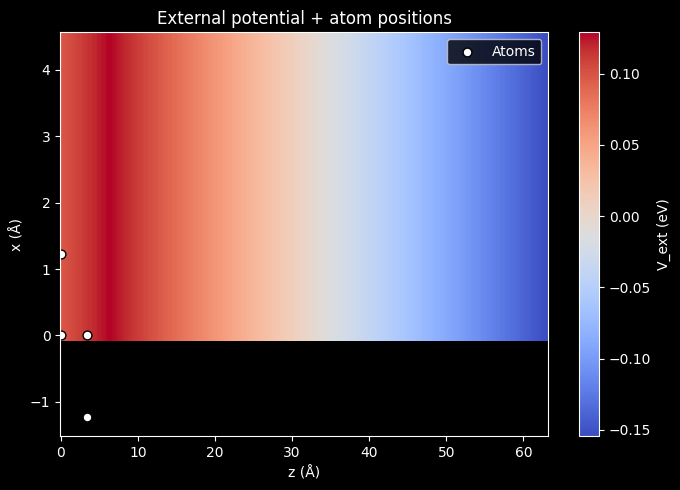

In [9]:
# Choose a small example field strength (A ≈ Ez in eV/Å)
A = 0.005
ext = ChargedPlanePotential(A=A, z_plane=z_plane)

# Visualize the external potential on the GPAW grid
Vext, (x, y, z) = compute_external_grid(calc0, ext)
plot_potential_slice(Vext, (x, y, z), atoms)
plt.show()


## Apply potential and run SCF (regular)


In [ ]:
calc = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.txt'))
atoms.calc = calc
_ = atoms.get_potential_energy()  # triggers a regular SCF with the external potential
gpw_out = os.path.join(out_dir, f'ab_gate_plane_A{A:.3f}.gpw')
calc.write(gpw_out)
gpw_out


## Band structure along a k-path


In [ ]:
bs = band_structure_with_path(calc, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
energies = bs.energies[0]
EF = calc.get_fermi_level()
E_shift = energies - EF

plt.figure(figsize=(6, 4))
for n in range(E_shift.shape[1]):
    plt.plot(E_shift[:, n])
plt.ylim(-1, 1)
plt.xlabel('k-path index')
plt.ylabel('Energy (eV)')
plt.title('Bilayer with gate potential')
plt.tight_layout()
plt.show()


# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


In [ ]:
from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 60           # pool of points before zooming (per full path)
_zoom_label = 'K'                 # special point to zoom around
_zoom_distance = 0.10             # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = True

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    for _Ez in fields:
        _Ez = float(_Ez)
        _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
        fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv):
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.


## Field sweep with interruption-safe saving
- Results are appended to a CSV after each field.
- If the CSV already contains an entry for a field value, it will be skipped (resume capability).


In [213]:
#fields = np.concatenate([np.linspace(0.01, 0.02, 11), np.linspace(0.02, 0.5, 21)])
fields = np.linspace(0, 0.1, 31)

In [214]:
# Define field values (eV/Å)

# Load existing results (if any) to enable resume
existing = {}
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                existing[float(row['Ez'])] = float(row['gap'])
            except Exception:
                pass

# Prepare CSV with header if new
new_file = not os.path.exists(sweep_csv)
if new_file:
    with open(sweep_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Ez', 'gap', 'gpw_path'])

results = []
for Ez in fields:
    Ez = float(Ez)
    if Ez in existing:
        log(f'Skipping Ez={Ez:.3f} eV/Å (already in results)')
        results.append((Ez, existing[Ez]))
        continue

    log(f'Running Ez={Ez:.3f} eV/Å')
    ext = ChargedPlanePotential(A=Ez, z_plane=z_plane)
    calcE = apply_external(calc0, atoms, ext, txt=os.path.join(out_dir, f'gate_A{Ez:.3f}.txt'))

    # Trigger a regular SCF with the external potential
    _ = atoms.get_potential_energy()

    # Save calculator state for this field
    gpw_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}.gpw')
    calcE.write(gpw_Ez)

    # Band structure and gap
    bsE = band_structure_with_path(calcE, path='GKMG', npoints=30, nbands=16, convergence_bands=8)
    energies = bsE.energies[0]
    EF = calcE.get_fermi_level()
    E = energies - EF
    gap = float(compute_gap(E))
    results.append((Ez, gap))

    # Append to CSV immediately (interruption-safe)
    with open(sweep_csv, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([f'{Ez:.6f}', f'{gap:.6f}', gpw_Ez])
    log(f'Saved Ez={Ez:.3f}, gap={gap:.4f} eV to CSV and {gpw_Ez}')

# Show summary
for Ez, gap in results:
    print(f'Ez={Ez:.3f} eV/Å -> gap={gap:.4f} eV')


[2025-12-13 15:03:36] Skipping Ez=0.000 eV/Å (already in results)
[2025-12-13 15:03:36] Running Ez=0.003 eV/Å

  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   nico@NicosPC
Date:   Sat Dec 13 15:11:47 2025
Arch:   x86_64
Pid:    2724
CWD:    /mnt/c/Users/Torto/PycharmProjects/DFT_QMB/2_graphene_bilayers/scripts/tight_binding/semiconductor
Python: 3.12.3
gpaw:   /home/nico/gpaw-env/lib/python3.12/site-packages/gpaw
_gpaw:  /home/nico/gpaw-env/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/nico/gpaw-env/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/nico/gpaw-env/lib/python3.12/site-packages/numpy (version 2.3.5)
scipy:  /home/nico/gpaw-env/lib/python3.12/site-packages/scipy (version 1.16.3)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  external: {A: 0.0033333333333333335,


KeyboardInterrupt: 

# High-resolution K-zoom bands (BandPath-based zooming) — compute from CSV list and SAVE to disk


In [220]:
from gpaw import GPAW  # noqa: F401 (ensures restart works for all gpw variants)
from ase.dft.kpoints import get_bandpath, kpoint_convert
import numpy as _np
import numpy as np
import csv as _csv

# Zoom settings inspired by save_pi_dft_bands (no pi-band filtering here)
_zoom_path_labels = ['G', 'M', 'K', 'G']
_zoom_npoints_pool = 100          # pool of points before zooming (per full path)
_zoom_label = 'K'                # special point to zoom around
_zoom_distance = 0.5            # diameter (1/Å) in Cartesian k-space for filtering
_nbands = 16
_conv = {'bands': 8}
_overwrite_zoom = False

# Build list of (Ez, gpw_path) strictly from CSV for resume-correctness
fields_from_csv = []
if os.path.exists(sweep_csv):
    with open(sweep_csv, 'r', newline='', encoding='utf-8') as _f:
        _reader = _csv.DictReader(_f)
        for _row in _reader:
            try:
                _Ez = float(_row['Ez'])
            except Exception:
                continue
            _gpw = _row.get('gpw_path') or os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
            fields_from_csv.append((_Ez, _gpw))
else:
    # fallback: use current fields list if CSV missing
    for _Ez in fields:
        _Ez = float(_Ez)
        _gpw = os.path.join(out_dir, f'ab_gate_plane_A{_Ez:.3f}.gpw')
        fields_from_csv.append((_Ez, _gpw))

for Ez, gpw_Ez in np.array(fields_from_csv):
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f'ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz')

    if not os.path.exists(gpw_Ez):
        log(f"GPW not found for Ez={Ez:.3f}: {gpw_Ez} — skipping K-zoom compute")
        continue

    if os.path.exists(npz_Ez) and not _overwrite_zoom:
        log(f"K-zoom NPZ already exists for Ez={Ez:.3f}: {npz_Ez} — skipping")
        continue

    # Ensure custom potential is registered before restart
    register_with_gpaw()

    # Restart calculator for this field
    atomsK, calcK = restart(gpw_Ez)

    # 1) Build the bandpath and k-point pool
    bp = get_bandpath(_zoom_path_labels, atomsK.cell, npoints=_zoom_npoints_pool)
    kpts = bp.kpts  # reduced coordinates (skpts)
    # Cartesian k-points (1/Å) for distance-based filtering
    kpts_cart = kpoint_convert(atomsK.cell, skpts_kc=kpts)

    # 2) Zoom: filter points within zoom_distance/2 of the special point (Cartesian)
    if _zoom_label not in _zoom_path_labels:
        log(f"Zoom label '{_zoom_label}' not in path {_zoom_path_labels} — skipping Ez={Ez:.3f}")
        continue

    k_special = kpoint_convert(atomsK.cell, skpts_kc=bp.special_points[_zoom_label])
    dist = np.linalg.norm(kpts_cart - k_special, axis=1)
    mask = dist < (_zoom_distance / 2.0)

    if not np.any(mask):
        log(f"No k-points within zoom window for Ez={Ez:.3f} (distance={_zoom_distance}). Consider increasing zoom_distance.")
        continue

    kpts_zoom = kpts[mask]
    kpts_cart_zoom = kpts_cart[mask]

    # 3) Build cumulative x-axis along the filtered path (Cartesian distance)
    if len(kpts_cart_zoom) >= 2:
        diffs = np.diff(kpts_cart_zoom, axis=0)
        seg = np.linalg.norm(diffs, axis=1)
        x = np.concatenate([[0.0], np.cumsum(seg)])
    else:
        x = np.array([0.0])

    # 4) Compute bands with explicit k-points (fixed_density)
    bs_calc = calcK.fixed_density(
        nbands=_nbands,
        symmetry='off',
        kpts=kpts_zoom,  # explicit reduced k-points
        convergence=_conv,
    )
    bs = bs_calc.band_structure()

    E = bs.energies[0]
    EF = float(bs_calc.get_fermi_level())
    E_shift = E - EF

    # 5) Save zoomed dataset
    try:
        os.makedirs(os.path.dirname(npz_Ez), exist_ok=True)
        np.savez_compressed(
            npz_Ez,
            x=np.asarray(x),
            kpts=np.asarray(kpts_zoom),
            kpts_cart=np.asarray(kpts_cart_zoom),
            E=np.asarray(E_shift),
            EF=float(EF),
            Ez=float(Ez),
            nbands=int(_nbands),
            conv_bands=int(_conv['bands']),
            path=np.array(_zoom_path_labels, dtype=object),
            npoints_pool=int(_zoom_npoints_pool),
            zoom_label=str(_zoom_label),
            zoom_distance=float(_zoom_distance),
        )
        log(f"Saved K-zoom bands for Ez={Ez:.3f} to {npz_Ez}")
    except Exception as _e:
        log(f"Error saving K-zoom bands for Ez={Ez:.3f}: {_e}")

# Done saving K-zoom band data for all available fields.


[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.000: ../gpw/ab_gate_plane_A0.000_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.001: ../gpw/ab_gate_plane_A0.001_bands_KZOOM.npz — skipping
[2025-12-13 19:04:26] K-zoom NPZ already exists for Ez=0.002: ..

In [221]:
import os
import numpy as np
import csv
from ase.dft.bandgap import bandgap

# Output CSV (simple and plot-friendly)
gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

results = []

fields_from_csv = np.array(fields_from_csv, dtype=object)
mask = fields_from_csv[:, 0].astype(float) > 0#< 0.1
fields_from_csv = fields_from_csv[mask]

# order by Ez
idx = np.argsort(fields_from_csv[:, 0].astype(float))
fields_from_csv = fields_from_csv[idx]

for Ez, gpw_Ez in fields_from_csv:
    Ez = float(Ez)
    npz_Ez = os.path.join(out_dir, f"ab_gate_plane_A{Ez:.3f}_bands_KZOOM.npz")

    if not os.path.exists(npz_Ez):
        log(f"K-zoom NPZ missing for Ez={Ez:.3f} — skipping gap")
        continue

    data = np.load(npz_Ez)
    E = data["E"]        # shape: (Nk, nbands), already shifted by EF

    # ---- band selection (as requested) ----
    # upper band closest to 0
    upper_mask = E > 0
    lower_mask = E < 0

    if not np.any(upper_mask) or not np.any(lower_mask):
        log(f"No valid upper/lower bands for Ez={Ez:.3f}")
        continue

    upper_band = np.min(E, axis=1, where=upper_mask, initial=np.inf)
    lower_band = np.max(E, axis=1, where=lower_mask, initial=-np.inf)

    # bandgap = minimum vertical separation
    gap_k = upper_band - lower_band
    gap = np.min(gap_k)

    results.append((Ez, gap))
    log(f"Ez={Ez:.3f} -> gap={gap:.6f} eV")

# ---- save to CSV ----
with open(gap_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Ez", "bandgap_eV"])
    writer.writerows(results)

log(f"Saved band gaps to {gap_csv}")


[2025-12-13 19:04:56] Ez=0.000 -> gap=0.143878 eV
[2025-12-13 19:04:56] Ez=0.000 -> gap=0.143878 eV
[2025-12-13 19:04:56] Ez=0.001 -> gap=0.184708 eV
[2025-12-13 19:04:56] Ez=0.001 -> gap=0.184708 eV
[2025-12-13 19:04:56] Ez=0.001 -> gap=0.184708 eV
[2025-12-13 19:04:56] Ez=0.001 -> gap=0.184708 eV
[2025-12-13 19:04:56] Ez=0.001 -> gap=0.184708 eV
[2025-12-13 19:04:56] Ez=0.002 -> gap=0.237724 eV
[2025-12-13 19:04:56] Ez=0.002 -> gap=0.237724 eV
[2025-12-13 19:04:56] Ez=0.002 -> gap=0.237724 eV
[2025-12-13 19:04:56] Ez=0.002 -> gap=0.237724 eV
[2025-12-13 19:04:56] Ez=0.002 -> gap=0.237724 eV
[2025-12-13 19:04:56] Ez=0.003 -> gap=0.252786 eV
[2025-12-13 19:04:56] Ez=0.003 -> gap=0.252786 eV
[2025-12-13 19:04:56] Ez=0.003 -> gap=0.252786 eV
[2025-12-13 19:04:56] Ez=0.003 -> gap=0.252786 eV
[2025-12-13 19:04:56] Ez=0.003 -> gap=0.252786 eV
[2025-12-13 19:04:56] Ez=0.003 -> gap=0.252786 eV
[2025-12-13 19:04:56] Ez=0.004 -> gap=0.260688 eV
[2025-12-13 19:04:56] Ez=0.004 -> gap=0.260688 eV


array([ True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

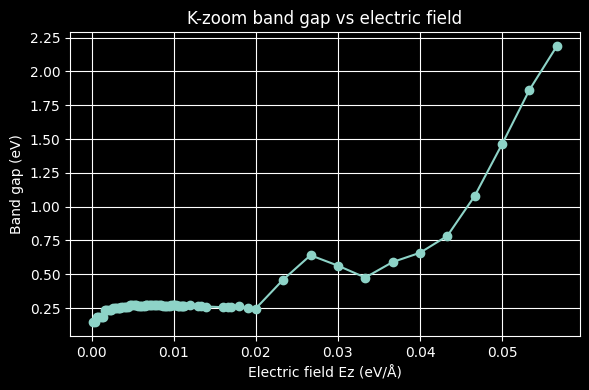

In [222]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

gap_csv = os.path.join(out_dir, "bandgaps_KZOOM.csv")

Ez_vals = []
gaps = []

with open(gap_csv, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        Ez_vals.append(float(row["Ez"]))
        gaps.append(float(row["bandgap_eV"]))

Ez_vals = np.array(Ez_vals)
gaps = np.array(gaps)

# sort by field
#Ez_vals_filtered = Ez_vals[Ez_vals < 0.025]
#gaps_filtered = gaps[Ez_vals < 0.025]
#idx = np.array(Ez_vals)
#idx = idx[Ez_vals < 0.001]
#idx = np.argsort(idx)
idx = np.argsort(Ez_vals)
Ez_vals_filtered = Ez_vals[idx]
gaps_filtered = gaps[idx]

# ---- plot ----
plt.figure(figsize=(6, 4))
plt.plot(Ez_vals_filtered, gaps_filtered, marker="o")
plt.xlabel("Electric field Ez (eV/Å)")
plt.ylabel("Band gap (eV)")
plt.title("K-zoom band gap vs electric field")
plt.grid(True)
plt.tight_layout()
plt.show()


In [133]:
idx = np.argsort(Ez_vals)
idx = idx[Ez_vals < 0.03]

Ez_vals[idx]

array([0.      , 0.000202, 0.000404, 0.000606, 0.000808, 0.00101 ,
       0.001212, 0.001414, 0.001616, 0.002   , 0.00202 , 0.002222,
       0.002424, 0.0025  , 0.002626, 0.002828, 0.00303 , 0.003232,
       0.003434, 0.003636, 0.003838, 0.00404 , 0.004242, 0.004444,
       0.004646, 0.004848, 0.005   , 0.005051, 0.005253, 0.005455,
       0.005657, 0.005859, 0.006061, 0.006263, 0.006465, 0.006667,
       0.006869, 0.007071, 0.007273, 0.007475, 0.0075  , 0.007677,
       0.007879, 0.008081, 0.008283, 0.008485, 0.008687, 0.008889,
       0.009091, 0.009293, 0.009495, 0.009697, 0.009899, 0.01    ,
       0.010101, 0.010303, 0.010505, 0.010707, 0.010909, 0.011   ,
       0.011111, 0.011313, 0.012   , 0.0125  , 0.013   , 0.014   ,
       0.015   , 0.016   , 0.017   , 0.018   , 0.019   , 0.02    ])

# Load saved full-path band data and PLOT for each field


In [224]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import numpy as np

fields_from_csv = fields_from_csv[fields_from_csv[:, 0]< 0.022]
# Convert to array for easy handling
fields_arr = np.array(fields_from_csv, dtype=object)

# Round Ez to 3 decimals (string-safe and filename-consistent)
Ez_rounded = np.round(fields_arr[:, 0].astype(float), 3)

# Build unique list, keeping first occurrence
_, unique_idx = np.unique(Ez_rounded, return_index=True)

fields_from_csv = np.array(
    [(Ez_rounded[i], fields_arr[i, 1]) for i in sorted(unique_idx)],
    dtype=object
)

gif_path = os.path.join(out_dir, "bands_KZOOM_vs_field.gif")
fps = 4

# Ensure sorted by Ez
fields_arr = np.array(fields_from_csv, dtype=object)
idx = np.argsort(fields_arr[:, 0].astype(float))
fields_sorted = fields_arr[idx]

frames = []

for _Ez, _gpw in fields_sorted:
    _Ez = float(_Ez)
    _npz_Ez = os.path.join(out_dir, f"ab_gate_plane_A{_Ez:.3f}_bands_KZOOM.npz")
    if not os.path.exists(_npz_Ez):
        log(f"Full-path NPZ not found for Ez={_Ez:.3f}: {_npz_Ez} — skipping frame")
        continue

    _data = np.load(_npz_Ez)
    _x = _data["x"]
    _E = _data["E"]

    # EXACT same plotting settings
    fig = plt.figure(figsize=(6, 4))
    for _n in range(_E.shape[1]):
        plt.plot(_x, _E[:, _n])
    plt.ylim(-1, 1)
    plt.xlabel("k (cumulative path)")
    plt.ylabel("E - E_F (eV)")
    plt.title(f"Full GKMG bands, Ez={_Ez:.3f} eV/Å")
    plt.tight_layout()

    # ---- backend-safe frame extraction ----
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    frames.append(frame)

    plt.close(fig)

# write gif
if len(frames) == 0:
    log("No frames collected — GIF not written.")
else:
    imageio.mimsave(gif_path, frames, fps=fps)
    log(f"Saved GIF to {gif_path}")


[2025-12-13 20:00:13] Saved GIF to ../gpw/bands_KZOOM_vs_field.gif


In [209]:
fields_arr

array([['0.0', '../gpw/ab_gate_plane_A0.000.gpw'],
       ['0.000202', '../gpw/ab_gate_plane_A0.000.gpw'],
       ['0.000404', '../gpw/ab_gate_plane_A0.000.gpw'],
       ['0.000606', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.000808', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.00101', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.001212', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.001414', '../gpw/ab_gate_plane_A0.001.gpw'],
       ['0.001616', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.001818', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.002', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.00202', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.002222', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.002424', '../gpw/ab_gate_plane_A0.002.gpw'],
       ['0.0025', '../gpw/ab_gate_plane_A0.003.gpw'],
       ['0.002626', '../gpw/ab_gate_plane_A0.003.gpw'],
       ['0.002828', '../gpw/ab_gate_plane_A0.003.gpw'],
       ['0.00303', '../gpw/ab_gate_plane_A0.003.gpw'],
     